In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("fivethirtyeight/uber-pickups-in-new-york-city")

print("Path to dataset files:", path)


100%|██████████| 109M/109M [00:03<00:00, 34.5MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/fivethirtyeight/uber-pickups-in-new-york-city/versions/2


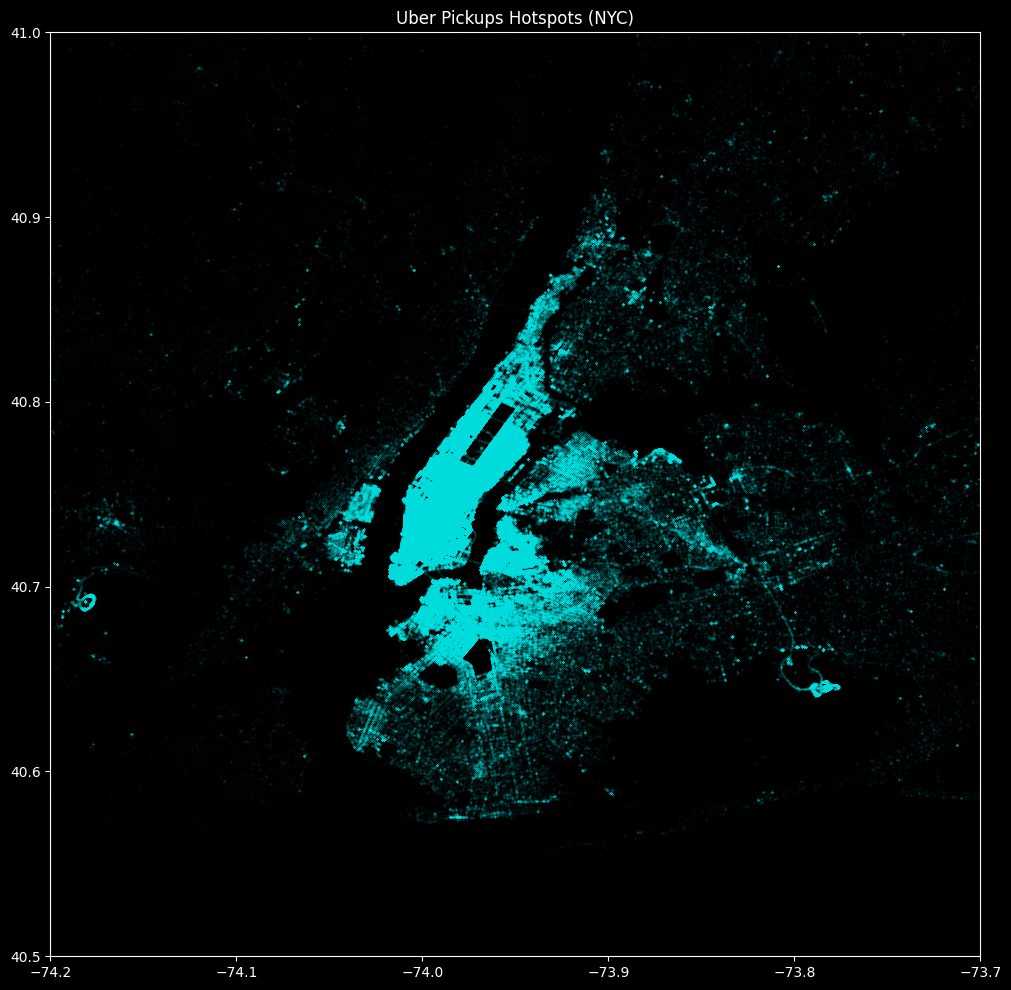

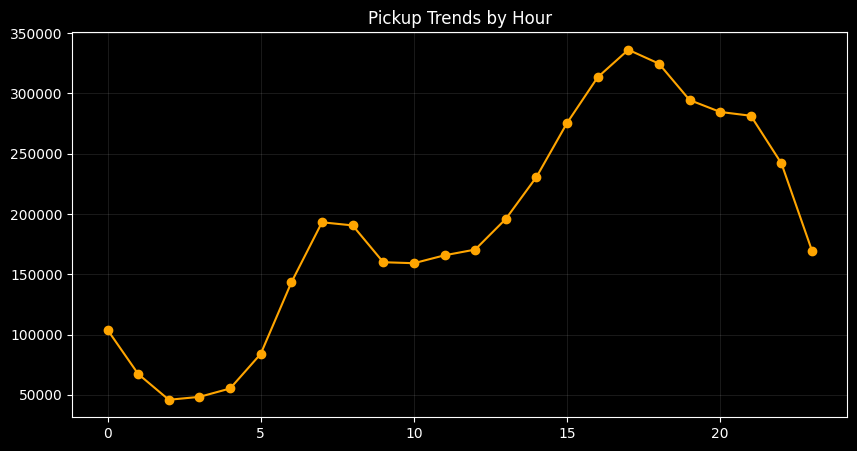

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import glob

data_path = "/root/.cache/kagglehub/datasets/fivethirtyeight/uber-pickups-in-new-york-city/versions/2"
csv_files = glob.glob(data_path + "/*.csv")

raw_data = []
for file in csv_files:

    temp_df = pd.read_csv(file, encoding='latin1')
    raw_data.append(temp_df)

uber_df = pd.concat(raw_data, ignore_index=True)

uber_df['Date/Time'] = pd.to_datetime(uber_df['Date/Time'])
uber_df['hour'] = uber_df['Date/Time'].dt.hour

plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(12, 12))

ax.scatter(uber_df['Lon'], uber_df['Lat'], s=0.05, alpha=0.1, color='cyan')
ax.set_xlim(-74.2, -73.7)
ax.set_ylim(40.5, 41.0)
ax.set_title('Uber Pickups Hotspots (NYC)')
plt.show()

hourly_counts = uber_df['hour'].value_counts().sort_index()
plt.figure(figsize=(10, 5))
plt.plot(hourly_counts.index, hourly_counts.values, marker='o', color='orange')
plt.title('Pickup Trends by Hour')
plt.grid(True, alpha=0.1)
plt.show()

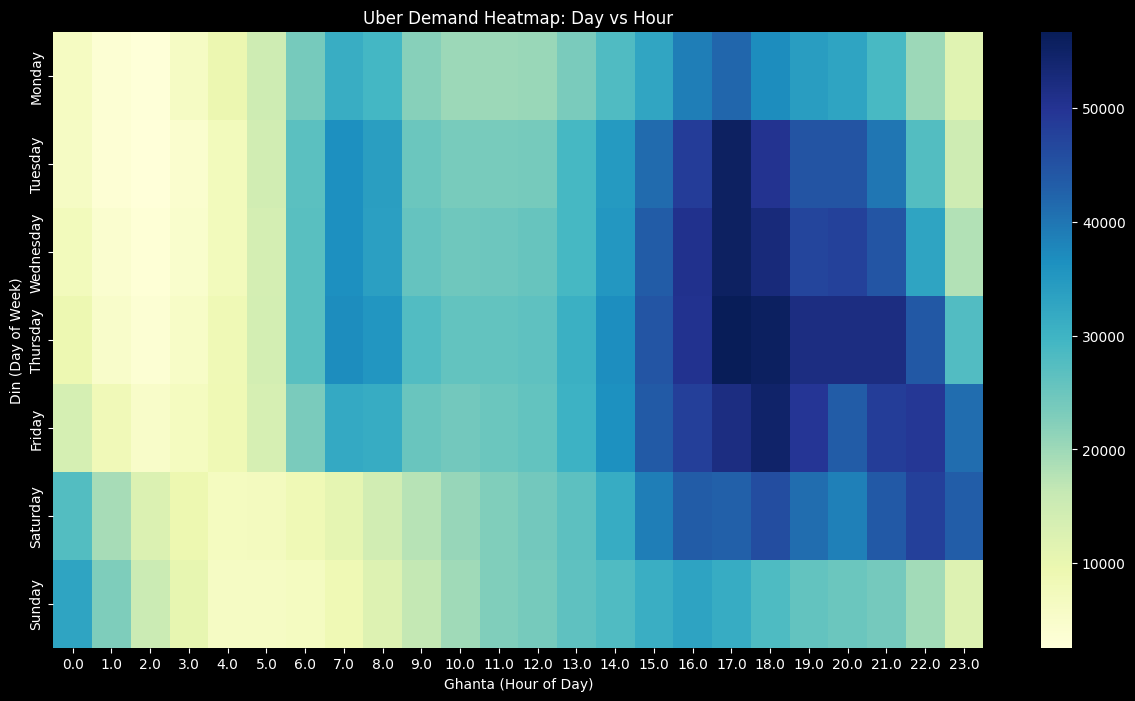

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


uber_df['Date/Time'] = pd.to_datetime(uber_df['Date/Time'])
uber_df['hour'] = uber_df['Date/Time'].dt.hour
uber_df['weekday'] = uber_df['Date/Time'].dt.day_name()


heat_data = uber_df.groupby(['weekday', 'hour']).size().unstack()


days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heat_data = heat_data.reindex(days_order)


plt.figure(figsize=(15, 8))
sns.heatmap(heat_data, cmap='YlGnBu')

plt.title('Uber Demand Heatmap: Day vs Hour')
plt.xlabel('Ghanta (Hour of Day)')
plt.ylabel('Din (Day of Week)')
plt.show()

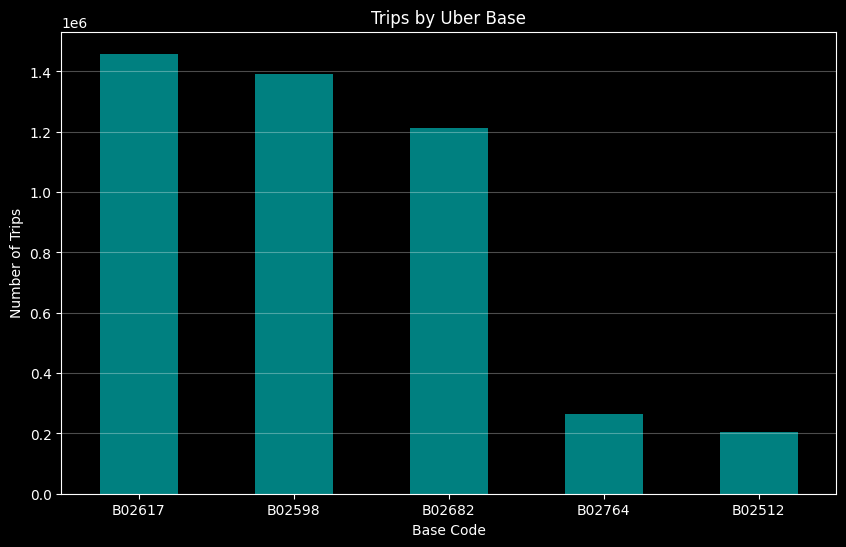

In [4]:

base_counts = uber_df['Base'].value_counts()


plt.figure(figsize=(10, 6))
base_counts.plot(kind='bar', color='teal')

plt.title('Trips by Uber Base')
plt.xlabel('Base Code')
plt.ylabel('Number of Trips')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()

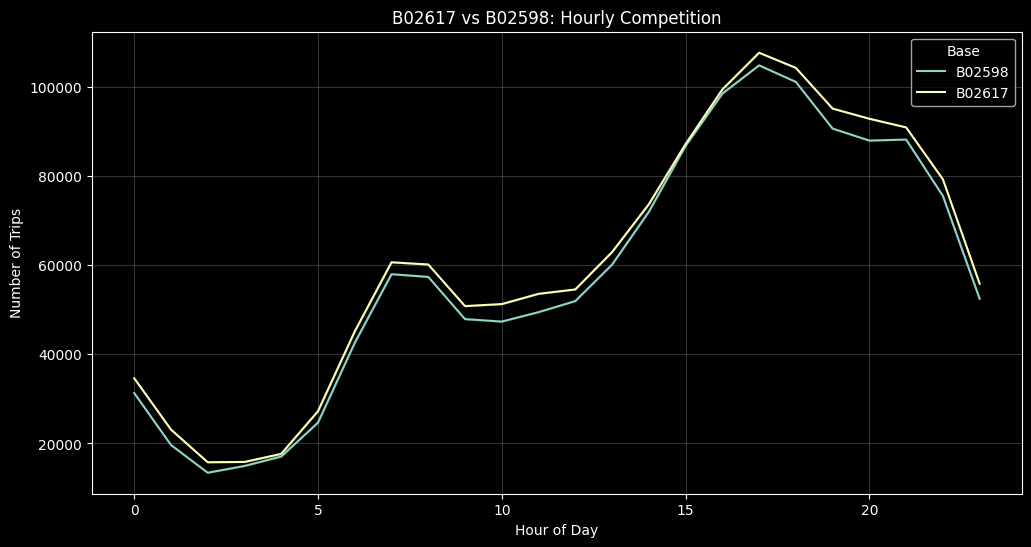

In [5]:

top_bases = uber_df[uber_df['Base'].isin(['B02617', 'B02598'])]


plt.figure(figsize=(12, 6))
sns.lineplot(data=top_bases, x='hour', y=top_bases.index, hue='Base', estimator='size')

plt.title('B02617 vs B02598: Hourly Competition')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')
plt.grid(True, alpha=0.2)
plt.show()